In [11]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Visual styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.autolayout': True, 'font.sans-serif': 'DejaVu Sans'})

# Reproducibility seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Libraries imported successfully. System ready.")


Libraries imported successfully. System ready.


In [12]:
data_path = "../data/sensor_data.csv"
print(f"Loading dataset from: {data_path}")
df = pd.read_csv(data_path)

print(f"\n--- DATASET SHAPE ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print(f"\n--- COLUMN DATA TYPES ---")
print(df.dtypes)

print(f"\n--- MISSING VALUES PER COLUMN ---")
print(df.isnull().sum())

print(f"\n--- DUPLICATE ROWS ---")
print(f"Total duplicate records: {df.duplicated().sum()}")

print(f"\n--- UNIQUE ASSETS & COMPONENTS ---")
print(f"Unique Assets: {df['asset_id'].nunique()} ({list(df['asset_id'].unique()[:5])}...)")
print(f"Unique Components: {df['component_id'].nunique()}")
print(f"Component Types: {list(df['component_type'].unique())}")

print(f"\n--- ANOMALY LABEL DISTRIBUTION ---")
anomaly_counts = df['anomaly_label'].value_counts()
anomaly_pcts = df['anomaly_label'].value_counts(normalize=True) * 100
for label, count in anomaly_counts.items():
    status_str = "Normal" if label == 0 else "Anomaly"
    print(f"  {status_str} (label={label}): {count} records ({anomaly_pcts[label]:.2f}%)")

print(f"\n--- SENSOR STATUS BREAKDOWN ---")
print(df['sensor_status'].value_counts())


Loading dataset from: ../data/sensor_data.csv

--- DATASET SHAPE ---
Rows: 20000, Columns: 18

--- COLUMN DATA TYPES ---
asset_id                       str
timestamp                      str
component_id                   str
component_type                 str
temperature                float64
vibration                  float64
oil_pressure               float64
fuel_pressure              float64
rpm                        float64
hydraulic_pressure         float64
battery_voltage            float64
coolant_temperature        float64
operating_hours              int64
load_percentage            float64
ambient_temperature        float64
sensor_status                  str
anomaly_label                int64
failure_within_50_hours      int64
dtype: object

--- MISSING VALUES PER COLUMN ---
asset_id                   0
timestamp                  0
component_id               0
component_type             0
temperature                0
vibration                  0
oil_pressure              

In [13]:
# 1. Parse timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 2. Check physical validity
physical_bounds = {
    'temperature': (0.0, 180.0),          # Celsius
    'vibration': (0.0, 30.0),             # mm/s RMS
    'oil_pressure': (0.0, 150.0),         # psi
    'fuel_pressure': (0.0, 120.0),        # psi
    'rpm': (0.0, 4000.0),                 # rev/min
    'hydraulic_pressure': (0.0, 300.0),   # bar/psi
    'battery_voltage': (12.0, 32.0),      # Volts DC
    'coolant_temperature': (0.0, 150.0),  # Celsius
    'operating_hours': (0, 50000),        # Hours
    'load_percentage': (0.0, 100.0),      # %
    'ambient_temperature': (-40.0, 70.0)  # Celsius
}

validity_report = []
for sensor, (low, high) in physical_bounds.items():
    below = (df[sensor] < low).sum()
    above = (df[sensor] > high).sum()
    validity_report.append({
        'Sensor': sensor,
        'Min Observed': round(df[sensor].min(), 2),
        'Max Observed': round(df[sensor].max(), 2),
        'Physical Min': low,
        'Physical Max': high,
        'Violations': below + above
    })

validity_df = pd.DataFrame(validity_report)
print("Physical Sensor Validation Report:")
print(validity_df.to_string(index=False))

print(f"\nEarliest timestamp: {df['timestamp'].min()} | Latest timestamp: {df['timestamp'].max()}")


Physical Sensor Validation Report:
             Sensor  Min Observed  Max Observed  Physical Min  Physical Max  Violations
        temperature         64.02        109.01           0.0         180.0           0
          vibration          1.24          8.57           0.0          30.0           0
       oil_pressure         49.86         88.08           0.0         150.0           0
      fuel_pressure         44.67         62.65           0.0         120.0           0
                rpm       1431.94       2166.80           0.0        4000.0           0
 hydraulic_pressure        118.72        163.09           0.0         300.0           0
    battery_voltage         21.40         25.14          12.0          32.0           0
coolant_temperature         68.78         91.46           0.0         150.0           0
    operating_hours        101.00        894.00           0.0       50000.0           0
    load_percentage         19.36        100.00           0.0         100.0          

--- OPERATIONAL SENSOR METRICS COMPARISON ---
                     Normal Mean  Normal Std  Anomaly Mean  Anomaly Std  \
vibration                  2.871       0.464         4.094        0.978   
operating_hours          439.395     145.092       607.688      137.360   
load_percentage           59.972       9.347        74.277        9.069   
temperature               76.380       3.490        84.354        4.833   
oil_pressure              75.027       3.066        69.174        4.116   
coolant_temperature       78.508       2.956        82.709        2.677   
hydraulic_pressure       148.248       4.164       144.300        5.953   
fuel_pressure             53.910       2.103        52.678        2.082   
battery_voltage           23.580       0.440        23.083        0.414   
rpm                     1800.502      90.013      1798.793       91.043   
ambient_temperature       30.001       5.042        30.027        4.981   

                     Mean Delta  Abs % Shift  
vibrat

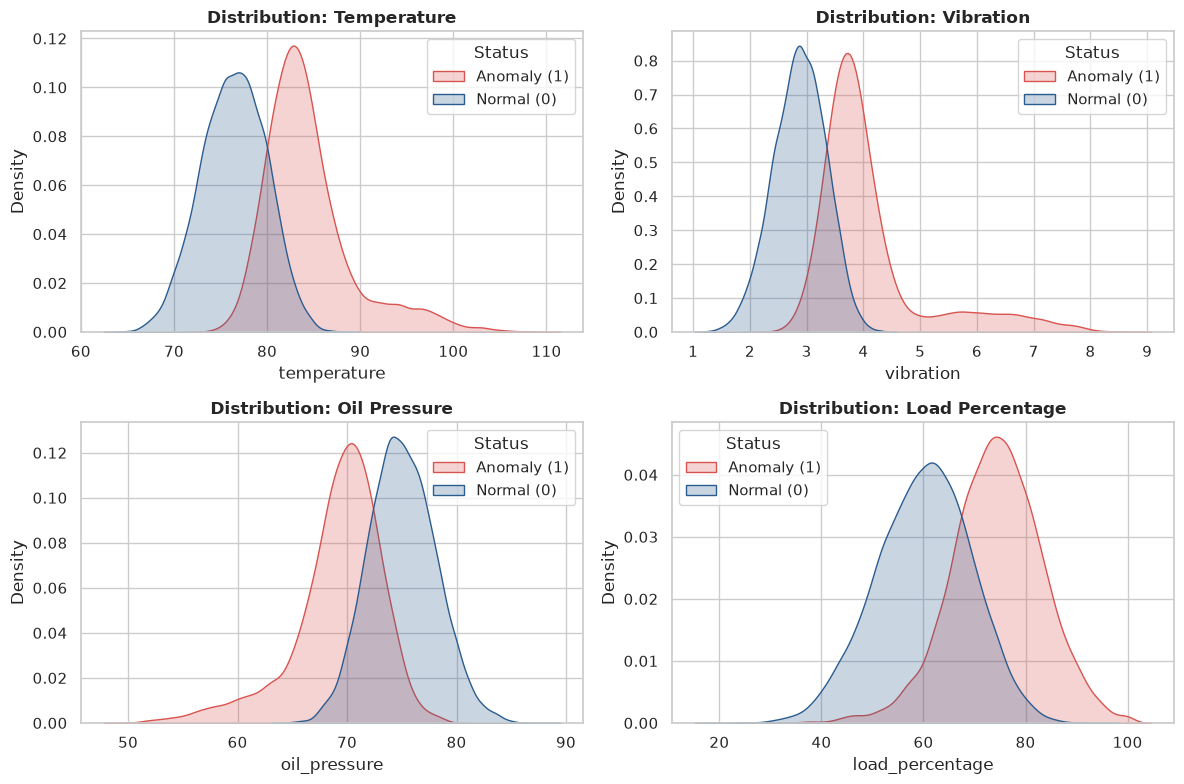

In [14]:
OPERATIONAL_FEATURES = [
    'temperature', 'vibration', 'oil_pressure', 'fuel_pressure', 'rpm',
    'hydraulic_pressure', 'battery_voltage', 'coolant_temperature',
    'operating_hours', 'load_percentage', 'ambient_temperature'
]

# Statistical divergence between Normal and Anomaly conditions
stats_comparison = pd.DataFrame({
    'Normal Mean': df[df['anomaly_label'] == 0][OPERATIONAL_FEATURES].mean(),
    'Normal Std': df[df['anomaly_label'] == 0][OPERATIONAL_FEATURES].std(),
    'Anomaly Mean': df[df['anomaly_label'] == 1][OPERATIONAL_FEATURES].mean(),
    'Anomaly Std': df[df['anomaly_label'] == 1][OPERATIONAL_FEATURES].std(),
})
stats_comparison['Mean Delta'] = stats_comparison['Anomaly Mean'] - stats_comparison['Normal Mean']
stats_comparison['Abs % Shift'] = (stats_comparison['Mean Delta'].abs() / stats_comparison['Normal Mean']) * 100
print("--- OPERATIONAL SENSOR METRICS COMPARISON ---")
print(stats_comparison.sort_values(by='Abs % Shift', ascending=False).round(3))

# Visualization of Top 4 Deviating Sensor Features
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
key_sensors = ['temperature', 'vibration', 'oil_pressure', 'load_percentage']

for ax, sensor in zip(axes.flatten(), key_sensors):
    sns.kdeplot(data=df, x=sensor, hue='anomaly_label', common_norm=False, fill=True, ax=ax, palette=['#2b5c8f', '#d9534f'])
    ax.set_title(f"Distribution: {sensor.replace('_', ' ').title()}", fontweight='bold')
    ax.legend(title='Status', labels=['Anomaly (1)', 'Normal (0)'])

plt.tight_layout()
plt.show()


In [15]:
# 1. Stratified Train/Test Split (80/20)
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=df['anomaly_label']
)

print(f"Training records: {train_df.shape[0]} | Test records: {test_df.shape[0]}")

# 2. Fit Scaler ONLY on Training Set to prevent leakage
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[OPERATIONAL_FEATURES])
X_test = scaler.transform(test_df[OPERATIONAL_FEATURES])

y_train = train_df['anomaly_label'].values
y_test = test_df['anomaly_label'].values

# Calculate baseline normal statistics for sensor attribution
normal_train_df = train_df[train_df['anomaly_label'] == 0]
baseline_means = normal_train_df[OPERATIONAL_FEATURES].mean().to_dict()
baseline_stds = normal_train_df[OPERATIONAL_FEATURES].std().to_dict()

print("Baseline statistics computed from healthy operating states:")
for feat in OPERATIONAL_FEATURES[:5]:
    print(f"  {feat:20s}: Mean = {baseline_means[feat]:.2f}, Std = {baseline_stds[feat]:.2f}")


Training records: 16000 | Test records: 4000
Baseline statistics computed from healthy operating states:
  temperature         : Mean = 76.39, Std = 3.50
  vibration           : Mean = 2.87, Std = 0.47
  oil_pressure        : Mean = 75.02, Std = 3.07
  fuel_pressure       : Mean = 53.92, Std = 2.10
  rpm                 : Mean = 1800.39, Std = 90.29


In [16]:
# Initialize and train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=None,
    class_weight='balanced',
    random_state=RANDOM_SEED,
    n_jobs=-1
)

# Fit supervised on X_train with ground-truth labels
rf_model.fit(X_train, y_train)
print("Random Forest training completed successfully.")

# Predict probabilities: column 1 = P(anomaly)
test_anomaly_scores = np.round(rf_model.predict_proba(X_test)[:, 1], 2)
test_pred_binary = rf_model.predict(X_test)
test_anomaly_status = np.where(test_pred_binary == 1, "ANOMALY", "NORMAL")

print(f"Sample Anomaly Probabilities (First 5 Test Records): {test_anomaly_scores[:5]}")
print(f"Sample Anomaly Status: {test_anomaly_status[:5]}")


Random Forest training completed successfully.
Sample Anomaly Probabilities (First 5 Test Records): [0.   0.04 0.99 0.55 0.27]
Sample Anomaly Status: ['NORMAL' 'NORMAL' 'ANOMALY' 'ANOMALY' 'NORMAL']


   RANDOM FOREST MODEL TEST SET EVALUATION        
Precision : 0.9349 (93.49%)
Recall    : 0.9428 (94.28%)
F1-Score  : 0.9388
ROC-AUC   : 0.9929

Classification Report:

              precision    recall  f1-score   support

      NORMAL       0.97      0.96      0.97      2584
     ANOMALY       0.93      0.94      0.94      1416

    accuracy                           0.96      4000
   macro avg       0.95      0.95      0.95      4000
weighted avg       0.96      0.96      0.96      4000



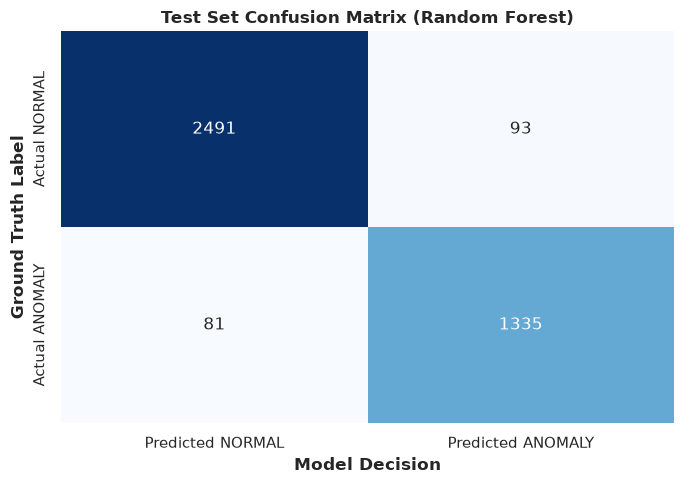

In [17]:
# Compute test set evaluation metrics
precision = precision_score(y_test, test_pred_binary)
recall = recall_score(y_test, test_pred_binary)
f1 = f1_score(y_test, test_pred_binary)
auc = roc_auc_score(y_test, test_anomaly_scores)
cm = confusion_matrix(y_test, test_pred_binary)

print("==================================================")
print("   RANDOM FOREST MODEL TEST SET EVALUATION        ")
print("==================================================")
print(f"Precision : {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall    : {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, test_pred_binary, target_names=["NORMAL", "ANOMALY"]))

# Confusion Matrix Heatmap
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted NORMAL', 'Predicted ANOMALY'],
    yticklabels=['Actual NORMAL', 'Actual ANOMALY'],
    cbar=False,
    ax=ax
)
ax.set_title("Test Set Confusion Matrix (Random Forest)", fontweight='bold', fontsize=12)
plt.ylabel("Ground Truth Label", fontweight='bold')
plt.xlabel("Model Decision", fontweight='bold')
plt.tight_layout()
plt.show()


--- SENSOR ATTRIBUTION RANKING (Average Standardized Deviation in Anomaly States) ---
   1. vibration              -> Mean Absolute Z-Score: 2.61 sigma
   2. temperature            -> Mean Absolute Z-Score: 2.28 sigma
   3. oil_pressure           -> Mean Absolute Z-Score: 1.90 sigma
   4. load_percentage        -> Mean Absolute Z-Score: 1.59 sigma
   5. coolant_temperature    -> Mean Absolute Z-Score: 1.46 sigma
   6. operating_hours        -> Mean Absolute Z-Score: 1.26 sigma
   7. battery_voltage        -> Mean Absolute Z-Score: 1.24 sigma
   8. hydraulic_pressure     -> Mean Absolute Z-Score: 1.21 sigma
   9. fuel_pressure          -> Mean Absolute Z-Score: 0.93 sigma
  10. rpm                    -> Mean Absolute Z-Score: 0.81 sigma
  11. ambient_temperature    -> Mean Absolute Z-Score: 0.80 sigma


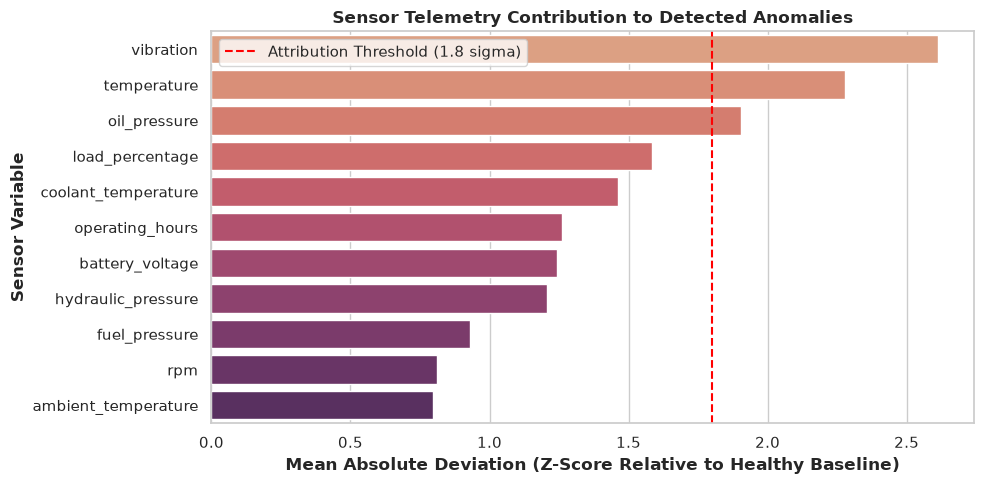

In [18]:
# Compute mean normalized deviation per sensor during anomaly states
anomaly_subset = test_df.iloc[np.where(test_pred_binary == 1)[0]][OPERATIONAL_FEATURES]
z_deviations = pd.DataFrame()
for f in OPERATIONAL_FEATURES:
    z_deviations[f] = (anomaly_subset[f] - baseline_means[f]).abs() / baseline_stds[f]

mean_attribution = z_deviations.mean().sort_values(ascending=False)

print("--- SENSOR ATTRIBUTION RANKING (Average Standardized Deviation in Anomaly States) ---")
for rank, (sensor, z_val) in enumerate(mean_attribution.items(), start=1):
    print(f"  {rank:2d}. {sensor:22s} -> Mean Absolute Z-Score: {z_val:.2f} sigma")

# Attribution Bar Plot
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    x=mean_attribution.values,
    y=mean_attribution.index,
    hue=mean_attribution.index,
    palette="flare",
    legend=False,
    ax=ax
)
ax.axvline(x=1.8, color='red', linestyle='--', label='Attribution Threshold (1.8 sigma)')
ax.set_title("Sensor Telemetry Contribution to Detected Anomalies", fontweight='bold')
ax.set_xlabel("Mean Absolute Deviation (Z-Score Relative to Healthy Baseline)", fontweight='bold')
ax.set_ylabel("Sensor Variable", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


In [19]:
# Artifact file paths
model_path = "../Models/anomaly_random_forest.joblib"
scaler_path = "../Models/sensor_scaler.joblib"
config_path = "../Models/anomaly_config.json"

# 1. Save Random Forest
joblib.dump(rf_model, model_path)

# 2. Save StandardScaler
joblib.dump(scaler, scaler_path)

# 3. Save Configuration & Baseline Metadata
anomaly_config = {
    "module": "MissionGuard Anomaly Detection",
    "version": "1.0.0",
    "algorithm": "RandomForestClassifier",
    "n_estimators": 150,
    "score_threshold": 0.50,
    "attribution_threshold_sigma": 1.8,
    "features": OPERATIONAL_FEATURES,
    "baseline_means": {k: round(v, 4) for k, v in baseline_means.items()},
    "baseline_stds": {k: round(v, 4) for k, v in baseline_stds.items()}
}

with open(config_path, "w") as f:
    json.dump(anomaly_config, f, indent=2)

print(f"Model saved to: {model_path}")
print(f"Scaler saved to: {scaler_path}")
print(f"Metadata config saved to: {config_path}")


Model saved to: ../Models/anomaly_random_forest.joblib
Scaler saved to: ../Models/sensor_scaler.joblib
Metadata config saved to: ../Models/anomaly_config.json


In [20]:
def predict_anomaly(sensor_data):
    '''
    FastAPI-compatible prediction function for MissionGuard Anomaly Detection.
    
    Parameters:
        sensor_data (dict or pd.Series): Incoming sensor telemetry record.
        
    Returns:
        dict: Structured response containing asset_id, component_id,
              calibrated anomaly_score [0.0, 1.0], anomaly_status,
              and list of contributing anomalous_sensors.
    '''
    if isinstance(sensor_data, pd.Series):
        sensor_data = sensor_data.to_dict()
    elif isinstance(sensor_data, pd.DataFrame):
        sensor_data = sensor_data.iloc[0].to_dict()
        
    asset_id = str(sensor_data.get("asset_id", "UNKNOWN"))
    component_id = str(sensor_data.get("component_id", "UNKNOWN"))
    
    # 1. Extract feature vector in exact model feature order
    feature_values = []
    for feat in OPERATIONAL_FEATURES:
        val = sensor_data.get(feat, baseline_means.get(feat, 0.0))
        if val is None or (isinstance(val, float) and np.isnan(val)):
            val = baseline_means.get(feat, 0.0)
        feature_values.append(float(val))
        
    # 2. Build single-row DataFrame with feature names
    df_vec = pd.DataFrame([feature_values], columns=OPERATIONAL_FEATURES)
    X_scaled = scaler.transform(df_vec)
    
    # 3. Model inference (Random Forest)
    score = float(np.round(rf_model.predict_proba(X_scaled)[0, 1], 2))
    
    # 5. Determine anomaly status
    status = "ANOMALY" if score >= 0.50 else "NORMAL"
    
    # 6. Perform sensor variable attribution
    anomalous_sensors = []
    if status == "ANOMALY":
        deviations = []
        for feat in OPERATIONAL_FEATURES:
            val = sensor_data.get(feat)
            if val is not None and not (isinstance(val, float) and np.isnan(val)):
                mean = baseline_means[feat]
                std = baseline_stds[feat] if baseline_stds[feat] > 0 else 1.0
                z = abs(float(val) - mean) / std
                if z >= 1.8:
                    deviations.append((feat, z))
        # Sort contributing sensors by deviation severity
        deviations.sort(key=lambda x: x[1], reverse=True)
        anomalous_sensors = [f for f, _ in deviations]
        
    return {
        "asset_id": asset_id,
        "component_id": component_id,
        "anomaly_score": score,
        "anomaly_status": status,
        "anomalous_sensors": anomalous_sensors
    }

# Demonstration on Sample Normal Reading
sample_normal = df[df['anomaly_label'] == 0].iloc[0].to_dict()
sample_normal['asset_id'] = "A002"
sample_normal['component_id'] = "C004"
result_normal = predict_anomaly(sample_normal)

# Demonstration on Sample Anomalous Reading
sample_anomaly = df[df['anomaly_label'] == 1].iloc[149].to_dict()
sample_anomaly['asset_id'] = "A001"
sample_anomaly['component_id'] = "C001"
result_anomaly = predict_anomaly(sample_anomaly)

print("--- DEMONSTRATION 1: NORMAL READING OUTPUT ---")
print(json.dumps(result_normal, indent=2))

print("\n--- DEMONSTRATION 2: ANOMALOUS READING OUTPUT ---")
print(json.dumps(result_anomaly, indent=2))


--- DEMONSTRATION 1: NORMAL READING OUTPUT ---
{
  "asset_id": "A002",
  "component_id": "C004",
  "anomaly_score": 0.0,
  "anomaly_status": "NORMAL",
  "anomalous_sensors": []
}

--- DEMONSTRATION 2: ANOMALOUS READING OUTPUT ---
{
  "asset_id": "A001",
  "component_id": "C001",
  "anomaly_score": 1.0,
  "anomaly_status": "ANOMALY",
  "anomalous_sensors": [
    "temperature",
    "vibration",
    "battery_voltage",
    "oil_pressure"
  ]
}
